# Hybrid residual GRAPE

Closed-loop Fock-state optimization with a fixed physics model plus a simple RBF/ridge residual correction.

The model used by the inner optimizer is

```text
logit(P_pred(u)) = logit(P_phys(u, p1)) + f_bb(u, p2)
```

where `u` is the 80-dimensional B-spline control vector, `p1` is the fixed Hamiltonian model, and `p2` is a small RBF/ridge residual fitted from binary measurement data.

This is intentionally closer to GRAPE than SPSA/CEM: the pulse optimizer uses `jax.grad` through the physics simulator and residual model. The experiment still only provides binomial measurements.


In [2]:
from dataclasses import replace
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from hybrid_residual_grape import (
    FockPhysicsModel,
    HybridGrapeConfig,
    PhysicsParams,
    RBFResidualConfig,
    SimulationConfig,
    append_dataset,
    empty_rbf_model,
    fit_rbf_residual,
    make_local_experiment_batch,
    optimize_hybrid_grape,
    sample_binomial_measurements,
)
from hybrid_residual_grape.config import khz_to_rad_per_us
from hybrid_residual_grape.residual import (
    hybrid_probability_from_physics,
    rbf_diagnostics,
    residual_logit,
    rbf_support,
)

jax.config.update("jax_enable_x64", True)


## Setup

The `physics_model` is what the optimizer believes. The `true_model` is only for this notebook's simulated experiment. In the real OPX1000/DGX setup, replace `measure_on_experiment` with the hardware call and delete/ignore the hidden true diagnostics.


In [3]:
seed = 1234
key = jax.random.key(seed)

q = SimulationConfig(
    n_cav=25,
    target_n=2,
    initial_cavity_n=0,
    initial_qubit_state=0,
    t_drive=1.408,
    ndt_drive=80,
    num_coeffs=20,
    spline_degree=2,
    spline_skip_left=2,
    spline_skip_right=2,
    param_clip=2.0,
)

p1 = PhysicsParams()
physics_model = FockPhysicsModel(q, p1)

# Hidden small mismatch used only to simulate the real experiment in this notebook.
true_params = PhysicsParams(
    chi=p1.chi + khz_to_rad_per_us(3.0),
    cavity_self_kerr=p1.cavity_self_kerr + khz_to_rad_per_us(0.12),
    cavity_detuning=khz_to_rad_per_us(2.0),
    qubit_detuning=khz_to_rad_per_us(-3.0),
    mu_qub=p1.mu_qub * 1.010,
    mu_cav=p1.mu_cav * 0.988,
    cavity_phase=0.025,
)
true_model = FockPhysicsModel(q, true_params)

print("parameter size:", physics_model.parameter_size)
print("basis endpoint max:", float(jnp.max(jnp.abs(physics_model.bsplines_edges[:, [0, -1]]))))
print("max active B-splines:", int(jnp.max(jnp.sum(physics_model.bsplines_mids > 1e-12, axis=0))))
print("chi [rad/us]:", p1.chi)
print("self Kerr [rad/us]:", p1.cavity_self_kerr)


parameter size: 80
basis endpoint max: 0.0
max active B-splines: 3
chi [rad/us]: 4.145440537691808
self Kerr [rad/us]: -0.0045308049250071996


## Real experiment hook

For now this samples a binomial distribution from the hidden simulator. On hardware, this function should send each `controls[i]` to the OPX1000, run `shots` repetitions of the selective photon-number test, and return successes and shot counts.

One shot is about `400 us` with reset, so `batch_size * shots * 400 us` is the measurement time per round.


In [4]:
shot_time_us = 400.0


def measure_on_experiment(controls, key, shots):
    return sample_binomial_measurements(
        true_model,
        controls,
        key,
        shots=shots,
    )


## Hyperparameters

The default values are deliberately modest for laptop testing. For OPX/DGX, increase `experiment_batch_size` and `shots_per_pulse` until measurement time is comparable to the GRAPE/RBF computation time.


In [6]:
rbf_config = RBFResidualConfig(
    max_centers=128,
    length_scale=0.18,
    ridge=5e-3,
    residual_clip=1.2,
    measurement_floor=1e-3,
)

grape_config = HybridGrapeConfig(
    maxiter=80,
    memory_size=10,
    noise_samples=8,
    control_noise_std=0.018,
    residual_support_penalty=0.12,
    residual_size_penalty=0.02,
    amplitude_l2=1e-4,
    smoothness_l2=1e-4,
    param_clip=q.param_clip,
    grad_clip_norm=20.0,
)

rounds = 12
experiment_batch_size = 12
shots_per_pulse = 1000
local_noise_std = 0.030

# OPX/DGX rule of thumb: increase experiment_batch_size and shots_per_pulse
# until measurement time is similar to the time spent fitting + GRAPE on DGX.
round_measurement_time_s = experiment_batch_size * shots_per_pulse * shot_time_us * 1e-6
print("binary measurements per round:", experiment_batch_size * shots_per_pulse)
print("measurement time per round [s]:", round_measurement_time_s)


binary measurements per round: 12000
measurement time per round [s]: 4.8


## Initialize state

We start from a small random pulse instead of exactly zero. For target Fock states, the exact zero pulse can have an unhelpful flat gradient.


In [7]:
key, init_key = jax.random.split(key)
best_controls = 0.02 * jax.random.normal(init_key, (physics_model.parameter_size,))
best_controls = jnp.clip(best_controls, -q.param_clip, q.param_clip)

residual_model = empty_rbf_model(physics_model.parameter_size, rbf_config)

dataset_controls = None
dataset_successes = None
dataset_shots = None
dataset_physics_probability = None

progress_rows = []
grape_histories = []

total_measurements = 0
best_measured = -1.0
best_true_diagnostic = float(true_model.photon_probability(best_controls))
print("initial true diagnostic P_n:", best_true_diagnostic)


initial true diagnostic P_n: 6.71593138067817e-07


## Physics-only GRAPE baseline

This is the comparison we need: optimize the pulse using only the imperfect physics model, with no RBF correction and no experiment feedback. The hidden true fidelity is shown only because this notebook simulates the experiment.


In [8]:
physics_only_residual = empty_rbf_model(physics_model.parameter_size, rbf_config)
physics_only_config = replace(
    grape_config,
    residual_support_penalty=0.0,
    residual_size_penalty=0.0,
    control_noise_std=0.0,
)
key, baseline_key = jax.random.split(key)
physics_only_controls, physics_only_history, physics_only_summary, _ = optimize_hybrid_grape(
    physics_model,
    physics_only_residual,
    best_controls,
    baseline_key,
    physics_only_config,
)
physics_only_pred = physics_model.photon_probability(physics_only_controls)
physics_only_true = true_model.photon_probability(physics_only_controls)

print("physics-only GRAPE predicted P_n:", float(physics_only_pred))
print("physics-only GRAPE hidden true P_n:", float(physics_only_true))
print("physics-only log10 infidelity diagnostic:", float(-jnp.log10(jnp.maximum(1.0 - physics_only_true, 1e-8))))


physics-only GRAPE predicted P_n: 7.065870104242672e-136
physics-only GRAPE hidden true P_n: 6.993462115653264e-136
physics-only log10 infidelity diagnostic: -0.0


## Run closed-loop hybrid residual GRAPE

Each round fits the RBF residual from all accumulated data, warm-starts GRAPE from the previous best pulse, measures the proposed pulse plus local noisy variants, and appends those measurements to the dataset.


In [9]:
pbar = tqdm(range(rounds), desc="hybrid residual GRAPE")

for round_index in pbar:
    if dataset_controls is not None and dataset_controls.shape[0] > 0:
        residual_model = fit_rbf_residual(
            dataset_controls,
            dataset_physics_probability,
            dataset_successes,
            dataset_shots,
            rbf_config,
        )
        diag = rbf_diagnostics(
            residual_model,
            dataset_controls,
            dataset_physics_probability,
            dataset_successes,
            dataset_shots,
        )
        fit_wmse = float(diag["weighted_mse"])
        active_centers = float(diag["active_centers"])
    else:
        residual_model = empty_rbf_model(physics_model.parameter_size, rbf_config)
        fit_wmse = float("nan")
        active_centers = 0.0

    proposed_controls, grape_history, grape_summary, key = optimize_hybrid_grape(
        physics_model,
        residual_model,
        best_controls,
        key,
        grape_config,
    )
    grape_histories.append(grape_history)

    experiment_controls, key = make_local_experiment_batch(
        proposed_controls,
        key,
        batch_size=experiment_batch_size,
        noise_std=local_noise_std,
        param_clip=q.param_clip,
        include_center=True,
    )

    physics_probability = physics_model.population_probability(experiment_controls)
    successes, shot_counts, true_probability, key = measure_on_experiment(
        experiment_controls,
        key,
        shots_per_pulse,
    )

    dataset_controls, dataset_successes, dataset_shots, dataset_physics_probability = append_dataset(
        dataset_controls,
        dataset_successes,
        dataset_shots,
        dataset_physics_probability,
        experiment_controls,
        successes,
        shot_counts,
        physics_probability,
    )
    total_measurements += int(experiment_batch_size * shots_per_pulse)

    measured = successes / shot_counts
    best_in_batch = int(jnp.argmax(measured))
    if float(measured[best_in_batch]) > best_measured:
        best_measured = float(measured[best_in_batch])
        best_true_diagnostic = float(true_probability[best_in_batch])
        best_controls = experiment_controls[best_in_batch]
    else:
        # Still warm-start the next inner GRAPE from the proposed center if the
        # high-shot estimate is close. This avoids freezing due to binomial noise.
        if float(measured[0]) > best_measured - 0.03:
            best_controls = proposed_controls

    progress_rows.append(
        jnp.array(
            [
                float(total_measurements),
                best_measured,
                best_true_diagnostic,
                float(measured[0]),
                float(true_probability[0]),
                float(grape_summary[1]),
                float(grape_summary[2]),
                float(grape_summary[3]),
                float(grape_summary[4]),
                fit_wmse,
                active_centers,
                float(dataset_controls.shape[0]),
            ]
        )
    )

    pbar.set_postfix(
        {
            "best_meas": f"{best_measured:.3f}",
            "best_true": f"{best_true_diagnostic:.4f}",
            "center_meas": f"{float(measured[0]):.3f}",
            "pred": f"{float(grape_summary[1]):.3f}",
            "data": dataset_controls.shape[0],
        }
    )

progress = jnp.stack(progress_rows) if progress_rows else jnp.zeros((0, 12))
print("total binary measurements:", total_measurements)
print("best measured P_n:", best_measured)
print("best true diagnostic P_n:", best_true_diagnostic)


hybrid residual GRAPE: 100%|██████████| 12/12 [04:25<00:00, 22.14s/it, best_meas=0.993, best_true=0.9923, center_meas=0.987, pred=0.993, data=144]

total binary measurements: 144000
best measured P_n: 0.9930000305175781
best true diagnostic P_n: 0.9923273376022459


## Plot progress

The model is allowed to propose pulses, but the pulse we trust is still selected by measured successes/shots. The hidden true curve is only for simulation diagnostics.


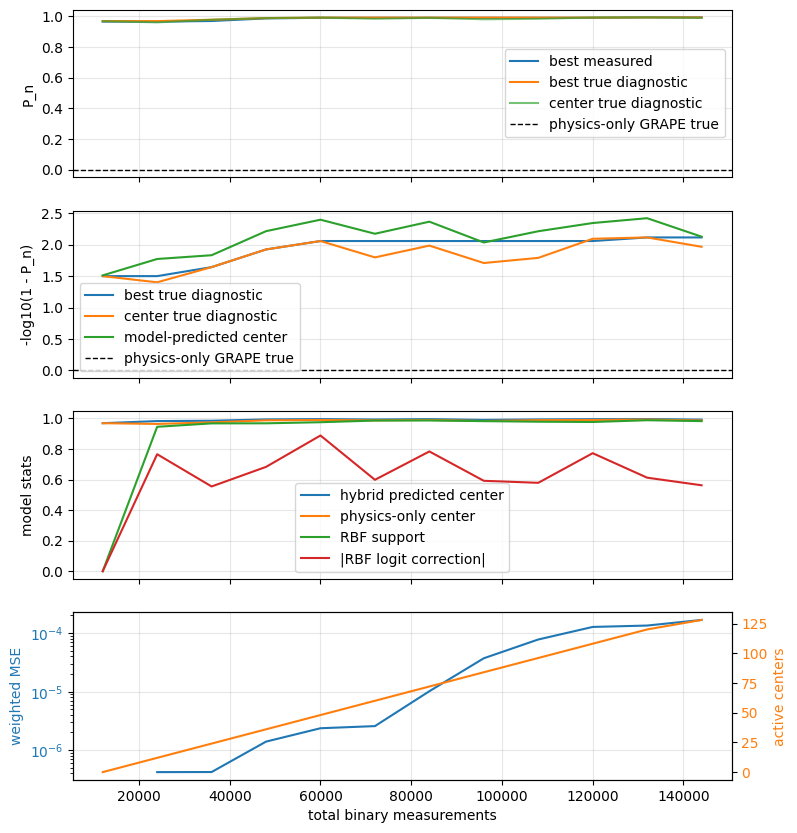

In [10]:
if len(progress_rows):
    progress = jnp.stack(progress_rows)

    def log_infidelity(probability):
        return -jnp.log10(jnp.maximum(1.0 - probability, 1e-8))

    fig, axes = plt.subplots(4, 1, figsize=(8.5, 10), sharex=True)

    axes[0].plot(progress[:, 0], progress[:, 1], label="best measured")
    axes[0].plot(progress[:, 0], progress[:, 2], label="best true diagnostic")
    axes[0].plot(progress[:, 0], progress[:, 4], label="center true diagnostic", alpha=0.65)
    axes[0].axhline(float(physics_only_true), color="black", linestyle="--", linewidth=1, label="physics-only GRAPE true")
    axes[0].set_ylabel("P_n")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(progress[:, 0], log_infidelity(progress[:, 2]), label="best true diagnostic")
    axes[1].plot(progress[:, 0], log_infidelity(progress[:, 4]), label="center true diagnostic")
    axes[1].plot(progress[:, 0], log_infidelity(progress[:, 5]), label="model-predicted center")
    axes[1].axhline(float(log_infidelity(physics_only_true)), color="black", linestyle="--", linewidth=1, label="physics-only GRAPE true")
    axes[1].set_ylabel("-log10(1 - P_n)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(progress[:, 0], progress[:, 5], label="hybrid predicted center")
    axes[2].plot(progress[:, 0], progress[:, 6], label="physics-only center")
    axes[2].plot(progress[:, 0], progress[:, 7], label="RBF support")
    axes[2].plot(progress[:, 0], progress[:, 8], label="|RBF logit correction|")
    axes[2].set_ylabel("model stats")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    ax_mse = axes[3]
    ax_centers = ax_mse.twinx()
    ax_mse.plot(progress[:, 0], jnp.maximum(progress[:, 9], 1e-8), label="RBF weighted MSE", color="tab:blue")
    ax_mse.set_yscale("log")
    ax_mse.set_ylabel("weighted MSE", color="tab:blue")
    ax_mse.tick_params(axis="y", labelcolor="tab:blue")
    ax_centers.plot(progress[:, 0], progress[:, 10], label="active centers", color="tab:orange")
    ax_centers.set_ylabel("active centers", color="tab:orange")
    ax_centers.tick_params(axis="y", labelcolor="tab:orange")
    ax_mse.set_xlabel("total binary measurements")
    ax_mse.grid(True, alpha=0.3)
    plt.show()
else:
    print("Run the loop first.")


## Dataset fit diagnostic

This checks whether the RBF residual is explaining the measured dataset without becoming wildly unsupported. In the real experiment, the right panel with hidden true probabilities would not exist.


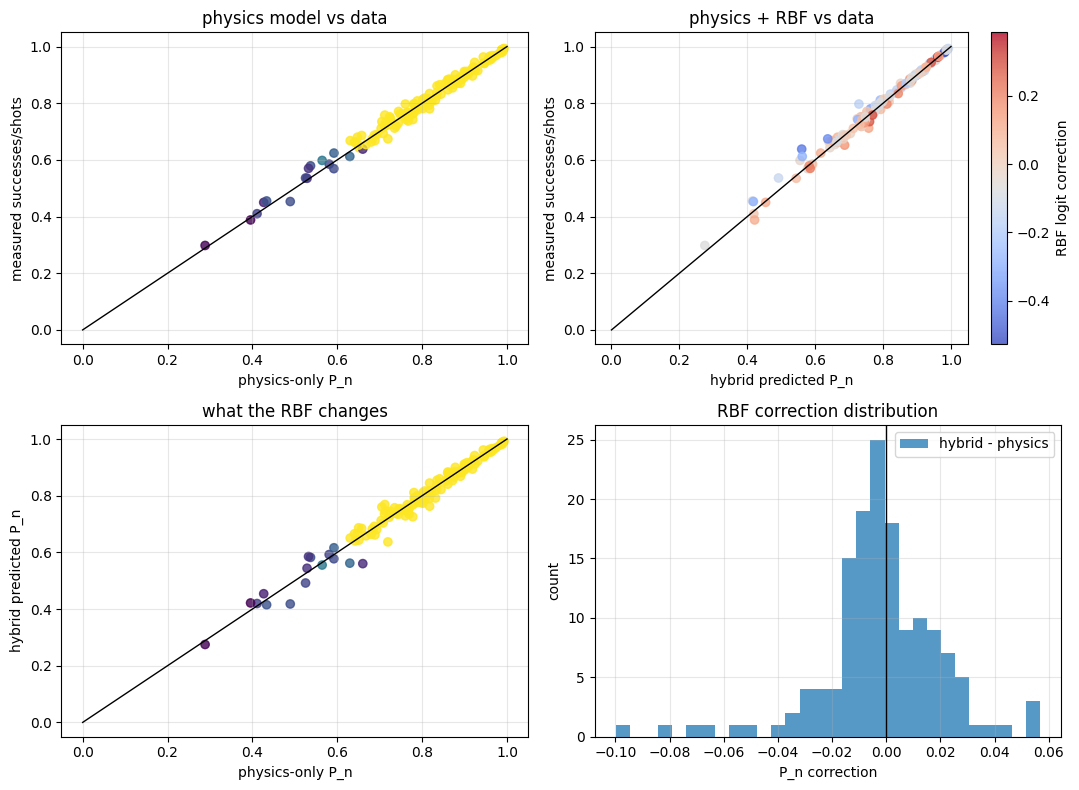

weighted MSE: 0.00024532565363793204
active centers: 128.0
mean |RBF logit correction|: 0.11196851248213534
max |RBF logit correction|: 0.5275494896471304


In [11]:
if dataset_controls is not None and dataset_controls.shape[0] > 0:
    residual_model = fit_rbf_residual(
        dataset_controls,
        dataset_physics_probability,
        dataset_successes,
        dataset_shots,
        rbf_config,
    )
    diag = rbf_diagnostics(
        residual_model,
        dataset_controls,
        dataset_physics_probability,
        dataset_successes,
        dataset_shots,
    )
    true_diag = true_model.population_probability(dataset_controls)
    hybrid_minus_physics = diag["predicted"] - dataset_physics_probability

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes = axes.ravel()

    axes[0].scatter(dataset_physics_probability, diag["measured"], c=diag["support"], cmap="viridis", alpha=0.8)
    axes[0].plot([0, 1], [0, 1], color="black", linewidth=1)
    axes[0].set_xlabel("physics-only P_n")
    axes[0].set_ylabel("measured successes/shots")
    axes[0].set_title("physics model vs data")
    axes[0].grid(True, alpha=0.3)

    sc = axes[1].scatter(diag["predicted"], diag["measured"], c=diag["residual"], cmap="coolwarm", alpha=0.8)
    axes[1].plot([0, 1], [0, 1], color="black", linewidth=1)
    axes[1].set_xlabel("hybrid predicted P_n")
    axes[1].set_ylabel("measured successes/shots")
    axes[1].set_title("physics + RBF vs data")
    axes[1].grid(True, alpha=0.3)
    fig.colorbar(sc, ax=axes[1], label="RBF logit correction")

    axes[2].scatter(dataset_physics_probability, diag["predicted"], c=diag["support"], cmap="viridis", alpha=0.8)
    axes[2].plot([0, 1], [0, 1], color="black", linewidth=1)
    axes[2].set_xlabel("physics-only P_n")
    axes[2].set_ylabel("hybrid predicted P_n")
    axes[2].set_title("what the RBF changes")
    axes[2].grid(True, alpha=0.3)

    axes[3].hist(jax.device_get(hybrid_minus_physics), bins=30, alpha=0.75, label="hybrid - physics")
    axes[3].axvline(0.0, color="black", linewidth=1)
    axes[3].set_xlabel("P_n correction")
    axes[3].set_ylabel("count")
    axes[3].set_title("RBF correction distribution")
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    plt.tight_layout()
    plt.show()

    print("weighted MSE:", float(diag["weighted_mse"]))
    print("active centers:", float(diag["active_centers"]))
    print("mean |RBF logit correction|:", float(jnp.mean(jnp.abs(diag["residual"]))))
    print("max |RBF logit correction|:", float(jnp.max(jnp.abs(diag["residual"]))))
else:
    print("No dataset yet.")


## RBF correction along a pulse path

This one-dimensional slice is often more informative than a scatter plot. It compares the physics model, hybrid model, and hidden true experiment along the line from the physics-only GRAPE pulse to the best closed-loop pulse.


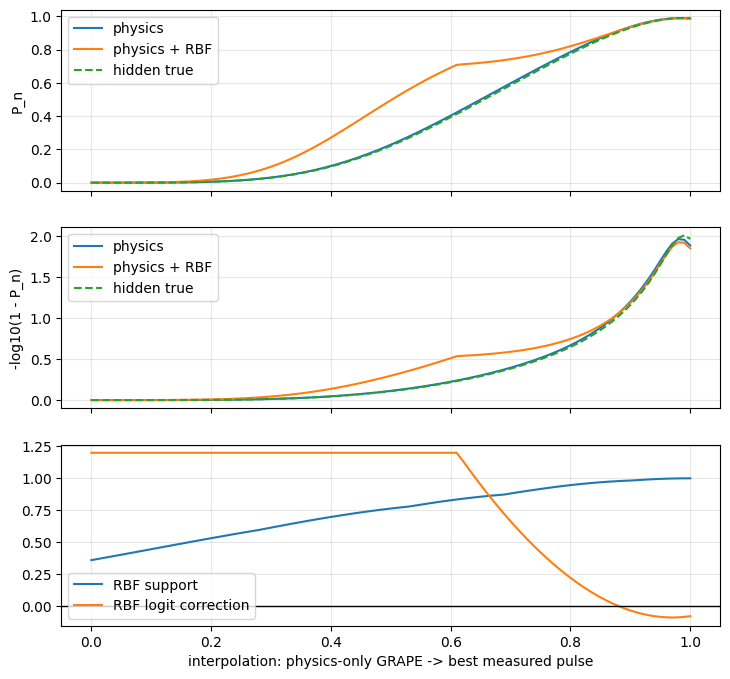

In [12]:
if dataset_controls is not None and dataset_controls.shape[0] > 0:
    residual_model = fit_rbf_residual(
        dataset_controls,
        dataset_physics_probability,
        dataset_successes,
        dataset_shots,
        rbf_config,
    )
    t = jnp.linspace(0.0, 1.0, 101)
    line_controls = (1.0 - t[:, None]) * physics_only_controls[None, :] + t[:, None] * best_controls[None, :]
    line_phys = physics_model.population_probability(line_controls)
    line_hybrid = hybrid_probability_from_physics(line_phys, residual_model, line_controls)
    line_true = true_model.population_probability(line_controls)
    line_support = rbf_support(residual_model, line_controls)
    line_residual = residual_logit(residual_model, line_controls)

    def log_infidelity(probability):
        return -jnp.log10(jnp.maximum(1.0 - probability, 1e-8))

    fig, axes = plt.subplots(3, 1, figsize=(8.5, 8), sharex=True)
    axes[0].plot(t, line_phys, label="physics")
    axes[0].plot(t, line_hybrid, label="physics + RBF")
    axes[0].plot(t, line_true, label="hidden true", linestyle="--")
    axes[0].set_ylabel("P_n")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(t, log_infidelity(line_phys), label="physics")
    axes[1].plot(t, log_infidelity(line_hybrid), label="physics + RBF")
    axes[1].plot(t, log_infidelity(line_true), label="hidden true", linestyle="--")
    axes[1].set_ylabel("-log10(1 - P_n)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(t, line_support, label="RBF support")
    axes[2].plot(t, line_residual, label="RBF logit correction")
    axes[2].axhline(0.0, color="black", linewidth=1)
    axes[2].set_xlabel("interpolation: physics-only GRAPE -> best measured pulse")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    plt.show()
else:
    print("Run the loop first.")


## Export current best pulse

`best_controls` is the 80-vector to send to the hardware waveform builder. It is clipped to `[-2, 2]` and follows the same 4 by 20 coefficient convention as the simulator.


In [13]:
print("best_controls shape:", best_controls.shape)
print("max abs coefficient:", float(jnp.max(jnp.abs(best_controls))))
print("best measured P_n:", best_measured)
print("best true diagnostic P_n:", best_true_diagnostic)


best_controls shape: (80,)
max abs coefficient: 1.339884163688913
best measured P_n: 0.9930000305175781
best true diagnostic P_n: 0.9923273376022459
